In [1]:
# ============================================================
# CELL 1 — Imports
# ============================================================

from pathlib import Path
import json
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

warnings.filterwarnings("ignore")

print("Imports successful.")

Imports successful.


In [2]:
# ============================================================
# CELL 2 — Project root
# ============================================================

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

print("Project root:")
print(PROJECT_ROOT)

Project root:
d:\downloads\misleading-health-infographic-detection


In [4]:
# ============================================================
# CELL 3 — Phase 13B directories
# ============================================================

PHASE12_DIR = (
    PROJECT_ROOT /
    "outputs" /
    "phase12"
)

PHASE13_DIR = (
    PROJECT_ROOT /
    "outputs" /
    "phase13"
)

PHASE13B_DIR = (
    PROJECT_ROOT /
    "outputs" /
    "phase13b"
)

CLAIMS_DIR = (
    PHASE13B_DIR /
    "claims"
)

MANIFEST_DIR = (
    PHASE13B_DIR /
    "manifests"
)

METRICS_DIR = (
    PHASE13B_DIR /
    "metrics"
)

VIS_DIR = (
    PHASE13B_DIR /
    "visualizations"
)

REPORTS_DIR = (
    PHASE13B_DIR /
    "reports"
)

for directory in [
    PHASE13B_DIR,
    CLAIMS_DIR,
    MANIFEST_DIR,
    METRICS_DIR,
    VIS_DIR,
    REPORTS_DIR
]:
    directory.mkdir(
        parents=True,
        exist_ok=True
    )

print("Phase 13B directories created.")

Phase 13B directories created.


In [5]:
# ============================================================
# CELL 4 — Load Phase 12 OCR → Phase 13B input
# ============================================================

PHASE13_INPUT = (
    PHASE12_DIR /
    "manifests" /
    "phase13_claim_extraction_input.csv"
)

if not PHASE13_INPUT.exists():
    raise FileNotFoundError(
        f"Input not found:\n{PHASE13_INPUT}"
    )

df = pd.read_csv(
    PHASE13_INPUT,
    encoding="utf-8-sig"
)

print("Input shape:", df.shape)

display(
    df.head()
)

Input shape: (100, 10)


,record_key,image_path,label,source,phase11_split,ocr_text,num_text_lines,ocr_char_count,ocr_word_count,ocr_quality
0,record_000000,D:\downloads\misleading-health-infographic-det...,1,MM-COVID19,MM-COVID19,WebMD,1,5,1,very_low
1,record_000001,D:\downloads\misleading-health-infographic-det...,1,MM-COVID19,MM-COVID19,WebMD,1,5,1,very_low
2,record_000002,D:\downloads\misleading-health-infographic-det...,1,MM-COVID19,MM-COVID19,WebMD,1,5,1,very_low
3,record_000003,D:\downloads\misleading-health-infographic-det...,1,MM-COVID19,MM-COVID19,WebMD,1,5,1,very_low
4,record_000004,D:\downloads\misleading-health-infographic-det...,1,MM-COVID19,MM-COVID19,WebMD,1,5,1,very_low


In [6]:
# ============================================================
# CELL 5 — Validate input
# ============================================================

required_columns = [
    "record_key",
    "image_path",
    "label",
    "source",
    "phase11_split",
    "ocr_text",
    "num_text_lines",
    "ocr_char_count",
    "ocr_word_count",
    "ocr_quality"
]

missing = [
    column
    for column in required_columns
    if column not in df.columns
]

if missing:
    raise ValueError(
        "Missing columns:\n" +
        "\n".join(missing)
    )

print("All required columns are present.")

print(
    "Records:",
    len(df)
)

print(
    "Empty OCR:",
    df["ocr_text"]
    .fillna("")
    .str.strip()
    .eq("")
    .sum()
)

All required columns are present.
Records: 100
Empty OCR: 0


In [7]:
# ============================================================
# CELL 6 — OCR normalization
# ============================================================

def normalize_ocr_text(text):

    if pd.isna(text):
        return ""

    text = str(text)

    # Normalize line endings
    text = re.sub(
        r"[\r\n]+",
        ". ",
        text
    )

    # Normalize whitespace
    text = re.sub(
        r"\s+",
        " ",
        text
    )

    # Remove repeated punctuation
    text = re.sub(
        r"([.!?,;:])\1+",
        r"\1",
        text
    )

    return text.strip()


df["clean_ocr_text"] = (
    df["ocr_text"]
    .apply(normalize_ocr_text)
)

print("OCR normalization complete.")

OCR normalization complete.


In [8]:
# ============================================================
# CELL 7 — Improved sentence segmentation
# ============================================================

def split_sentences(text):

    if not text:
        return []

    text = str(text)

    # Treat line breaks as sentence boundaries
    text = re.sub(
        r"[\r\n]+",
        ". ",
        text
    )

    # Separate common punctuation boundaries
    parts = re.split(
        r"(?<=[.!?])\s+"
        r"|;\s+"
        r"|\|\s+"
        r"|•\s*"
        r"|-\s+(?=[A-Z])",
        text
    )

    sentences = []

    for part in parts:

        part = part.strip()

        if len(part) >= 5:
            sentences.append(part)

    return sentences


df["sentences"] = (
    df["clean_ocr_text"]
    .apply(split_sentences)
)

df["num_sentences"] = (
    df["sentences"]
    .apply(len)
)

print(
    "Total sentence candidates:",
    df["num_sentences"].sum()
)

Total sentence candidates: 282


In [9]:
# ============================================================
# CELL 8 — Expanded health concepts
# ============================================================

HEALTH_CONCEPTS = {

    "disease_conditions": [
        "disease",
        "diseases",
        "diabetes",
        "cancer",
        "heart disease",
        "cardiovascular",
        "hypertension",
        "high blood pressure",
        "low blood pressure",
        "obesity",
        "asthma",
        "infection",
        "infections",
        "virus",
        "viral",
        "bacterial",
        "covid",
        "covid-19",
        "flu",
        "influenza",
        "arthritis"
    ],

    "symptoms": [
        "symptom",
        "symptoms",
        "pain",
        "fever",
        "fatigue",
        "headache",
        "nausea",
        "cough",
        "inflammation"
    ],

    "nutrition": [
        "food",
        "foods",
        "diet",
        "nutrition",
        "nutrient",
        "nutrients",
        "protein",
        "carbohydrate",
        "carbs",
        "fat",
        "fats",
        "sugar",
        "salt",
        "sodium",
        "calorie",
        "calories",
        "fiber",
        "fibre"
    ],

    "supplements": [
        "vitamin",
        "vitamins",
        "vitamin d",
        "vitamin c",
        "vitamin b",
        "iron",
        "calcium",
        "zinc",
        "magnesium",
        "supplement",
        "supplements"
    ],

    "medication_treatment": [
        "medicine",
        "medication",
        "drug",
        "drugs",
        "treatment",
        "therapy",
        "therapeutic",
        "vaccine",
        "vaccines",
        "vaccination",
        "dose",
        "dosage"
    ],

    "lifestyle": [
        "exercise",
        "physical activity",
        "workout",
        "walking",
        "running",
        "sleep",
        "stress",
        "smoking",
        "alcohol",
        "weight loss",
        "weight gain",
        "obesity"
    ],

    "body_systems": [
        "heart",
        "brain",
        "blood",
        "blood sugar",
        "blood glucose",
        "immune system",
        "immunity",
        "lungs",
        "liver",
        "kidney",
        "kidneys",
        "gut",
        "digestive system"
    ],

    "medical_context": [
        "health",
        "healthy",
        "medical",
        "doctor",
        "patient",
        "patients",
        "clinical",
        "hospital",
        "healthcare",
        "public health"
    ]
}

print(
    "Health concept groups:",
    len(HEALTH_CONCEPTS)
)

Health concept groups: 8


In [10]:
# ============================================================
# CELL 9 — Flatten health concepts
# ============================================================

ALL_HEALTH_TERMS = []

for category, terms in HEALTH_CONCEPTS.items():

    for term in terms:

        ALL_HEALTH_TERMS.append(
            term.lower()
        )

ALL_HEALTH_TERMS = sorted(
    set(ALL_HEALTH_TERMS),
    key=len,
    reverse=True
)

print(
    "Unique health terms:",
    len(ALL_HEALTH_TERMS)
)

Unique health terms: 105


In [11]:
# ============================================================
# CELL 10 — Claim cues
# ============================================================

CLAUSAL_CUES = [
    "cause",
    "causes",
    "caused",
    "lead to",
    "leads to",
    "result in",
    "results in",
    "increase",
    "increases",
    "increased",
    "decrease",
    "decreases",
    "decreased",
    "reduce",
    "reduces",
    "reduced",
    "lower",
    "lowers",
    "higher",
    "raise",
    "raises",
    "boost",
    "boosts",
    "improve",
    "improves",
    "protect",
    "protects",
    "prevent",
    "prevents",
    "cure",
    "cures",
    "treat",
    "treats",
    "heal",
    "heals",
    "associated with",
    "linked to",
    "related to",
    "connected to"
]

ASSERTION_CUES = [
    "is",
    "are",
    "was",
    "were",
    "can",
    "may",
    "might",
    "could",
    "has",
    "have",
    "helps",
    "help",
    "known to",
    "shown to",
    "found to",
    "studies show",
    "research shows",
    "evidence suggests"
]

RECOMMENDATION_CUES = [
    "should",
    "must",
    "need to",
    "needs to",
    "recommended",
    "recommend",
    "avoid",
    "include",
    "eat",
    "take",
    "drink",
    "exercise",
    "consult",
    "talk to your doctor"
]

UNCERTAINTY_CUES = [
    "may",
    "might",
    "could",
    "possibly",
    "potentially",
    "suggests",
    "suggest",
    "likely",
    "unlikely"
]

NEGATION_CUES = [
    "not",
    "no",
    "never",
    "without",
    "doesn't",
    "does not",
    "cannot",
    "can't"
]

print("Claim cue dictionaries loaded.")

Claim cue dictionaries loaded.


In [12]:
# ============================================================
# CELL 11 — Health concept detection
# ============================================================

def detect_health_categories(text):

    text_lower = text.lower()

    categories = []

    for category, terms in HEALTH_CONCEPTS.items():

        found = False

        for term in terms:

            if term.lower() in text_lower:
                found = True
                break

        if found:
            categories.append(category)

    return categories


def detect_health_terms(text):

    text_lower = text.lower()

    found_terms = []

    for term in ALL_HEALTH_TERMS:

        if term in text_lower:
            found_terms.append(term)

    return list(
        dict.fromkeys(found_terms)
    )

In [13]:
# ============================================================
# CELL 12 — Candidate claim scoring
# ============================================================

def score_claim_candidate(sentence):

    text = sentence.lower().strip()

    score = 0

    health_terms = detect_health_terms(
        text
    )

    health_categories = detect_health_categories(
        text
    )

    # --------------------------------------------------------
    # Health concept
    # --------------------------------------------------------

    if health_terms:
        score += 2

    if len(health_terms) >= 2:
        score += 1

    # --------------------------------------------------------
    # Causal / medical relationship
    # --------------------------------------------------------

    causal_hits = [
        cue
        for cue in CLAUSAL_CUES
        if cue in text
    ]

    if causal_hits:
        score += 2

    # --------------------------------------------------------
    # Assertion
    # --------------------------------------------------------

    assertion_hits = [
        cue
        for cue in ASSERTION_CUES
        if cue in text
    ]

    if assertion_hits:
        score += 1

    # --------------------------------------------------------
    # Recommendation
    # --------------------------------------------------------

    recommendation_hits = [
        cue
        for cue in RECOMMENDATION_CUES
        if cue in text
    ]

    if recommendation_hits:
        score += 2

    # --------------------------------------------------------
    # Quantitative statement
    # --------------------------------------------------------

    number_hits = re.findall(
        r"\b\d+(?:\.\d+)?\s*%"
        r"|\b\d+(?:\.\d+)?\s*"
        r"(?:mg|g|kg|ml|l|days?|weeks?|months?|years?)\b",
        text,
        flags=re.IGNORECASE
    )

    if number_hits and health_terms:
        score += 2

    # --------------------------------------------------------
    # Very short text penalty
    # --------------------------------------------------------

    if len(text.split()) <= 3:
        score -= 2

    return {
        "score": score,
        "health_terms": health_terms,
        "health_categories": health_categories,
        "causal_hits": causal_hits,
        "assertion_hits": assertion_hits,
        "recommendation_hits": recommendation_hits,
        "number_hits": number_hits
    }

In [14]:
# ============================================================
# CELL 13 — Candidate extraction
# ============================================================

candidate_records = []

for _, row in df.iterrows():

    for sentence_index, sentence in enumerate(
        row["sentences"]
    ):

        analysis = score_claim_candidate(
            sentence
        )

        # Candidate threshold
        is_candidate = (
            analysis["score"] >= 3
        )

        if is_candidate:

            candidate_records.append({

                "record_key":
                    row["record_key"],

                "image_path":
                    row["image_path"],

                "label":
                    row["label"],

                "source":
                    row["source"],

                "phase11_split":
                    row["phase11_split"],

                "sentence_index":
                    sentence_index,

                "claim_text":
                    sentence,

                "candidate_score":
                    analysis["score"],

                "health_terms":
                    analysis["health_terms"],

                "health_categories":
                    analysis["health_categories"],

                "causal_cues":
                    analysis["causal_hits"],

                "assertion_cues":
                    analysis["assertion_hits"],

                "recommendation_cues":
                    analysis["recommendation_hits"],

                "quantitative_values":
                    analysis["number_hits"]
            })


refined_claims = pd.DataFrame(
    candidate_records
)

print(
    "Refined candidate claims:",
    len(refined_claims)
)

print(
    "Records represented:",
    refined_claims[
        "record_key"
    ].nunique()
    if len(refined_claims)
    else 0
)

display(
    refined_claims.head(20)
)

Refined candidate claims: 12
Records represented: 8


,record_key,image_path,label,source,phase11_split,sentence_index,claim_text,candidate_score,health_terms,health_categories,causal_cues,assertion_cues,recommendation_cues,quantitative_values
0,record_000036,D:\downloads\misleading-health-infographic-det...,1,MMCoVar,MMCoVar,1,OUE TO NON-RECEIPT OF VACCINE DOSES.,3,"[vaccine, dose]",[medication_treatment],[],[],[],[]
1,record_000050,D:\downloads\misleading-health-infographic-det...,0,MMCoVar,MMCoVar,4,"""to help reduce hesitance.",3,[],[],[reduce],[help],[],[]
2,record_000050,D:\downloads\misleading-health-infographic-det...,0,MMCoVar,MMCoVar,9,Visit the COVID-19 Information Center for,4,"[covid-19, covid]",[disease_conditions],[],[is],[],[]
3,record_000062,D:\downloads\misleading-health-infographic-det...,1,MMCoVar,MMCoVar,2,Each vial contains 5 doses of 0.5 mL.,4,[dose],[medication_treatment],[],[],[],[0.5 ml]
4,record_000062,D:\downloads\misleading-health-infographic-det...,1,MMCoVar,MMCoVar,13,Each vial contains 5 doses of 0.5 mL.,4,[dose],[medication_treatment],[],[],[],[0.5 ml]
5,record_000073,D:\downloads\misleading-health-infographic-det...,1,MMCoVar,MMCoVar,2,contains 6 doses of 0.3 mL.,4,[dose],[medication_treatment],[],[],[],[0.3 ml]
6,record_000107,D:\downloads\misleading-health-infographic-det...,0,ReCOVery,ReCOVery,1,OUE TO NON-RECEIPT OF VACCINE DOSES.,3,"[vaccine, dose]",[medication_treatment],[],[],[],[]
7,record_000121,D:\downloads\misleading-health-infographic-det...,1,ReCOVery,ReCOVery,4,"""to help reduce hesitance.",3,[],[],[reduce],[help],[],[]
8,record_000121,D:\downloads\misleading-health-infographic-det...,1,ReCOVery,ReCOVery,9,Visit the COVID-19 Information Center for,4,"[covid-19, covid]",[disease_conditions],[],[is],[],[]
9,record_000136,D:\downloads\misleading-health-infographic-det...,0,ReCOVery,ReCOVery,2,Each vial contains 5 doses of 0.5 mL.,4,[dose],[medication_treatment],[],[],[],[0.5 ml]


In [15]:
# ============================================================
# CELL 14 — Remove obvious OCR metadata
# ============================================================

NON_CLAIM_PATTERNS = [
    r"^webmd$",
    r"^health tips?$",
    r"^health$",
    r"^medical news$",
    r"^www\.",
    r"^https?://",
    r"^follow us",
    r"^subscribe",
    r"^copyright",
    r"^\d{4}$",
    r"^\d+\s*h$",
    r"^\d+\s*hours?$"
]


def looks_like_metadata(text):

    text_lower = text.lower().strip()

    for pattern in NON_CLAIM_PATTERNS:

        if re.match(
            pattern,
            text_lower
        ):
            return True

    return False


before_count = len(
    refined_claims
)

if len(refined_claims) > 0:

    refined_claims = refined_claims[
        ~refined_claims[
            "claim_text"
        ].apply(
            looks_like_metadata
        )
    ].copy()

after_count = len(
    refined_claims
)

print(
    "Removed metadata-like candidates:",
    before_count - after_count
)

print(
    "Remaining candidates:",
    after_count
)

Removed metadata-like candidates: 0
Remaining candidates: 12


In [16]:
# ============================================================
# CELL 15 — Improved claim type classification
# ============================================================

def classify_refined_claim_type(row):

    text = row["claim_text"].lower()

    # --------------------------------------------------------
    # Recommendation
    # --------------------------------------------------------

    if any(
        cue in text
        for cue in RECOMMENDATION_CUES
    ):
        return "recommendation"

    # --------------------------------------------------------
    # Causal
    # --------------------------------------------------------

    if any(
        cue in text
        for cue in [
            "cause",
            "causes",
            "caused",
            "lead to",
            "leads to",
            "result in",
            "results in"
        ]
    ):
        return "causal"

    # --------------------------------------------------------
    # Preventive
    # --------------------------------------------------------

    if any(
        cue in text
        for cue in [
            "prevent",
            "prevents",
            "prevention",
            "protect",
            "protects"
        ]
    ):
        return "preventive"

    # --------------------------------------------------------
    # Therapeutic
    # --------------------------------------------------------

    if any(
        cue in text
        for cue in [
            "treat",
            "treats",
            "treatment",
            "cure",
            "cures",
            "therapy",
            "therapeutic",
            "heal",
            "heals"
        ]
    ):
        return "therapeutic"

    # --------------------------------------------------------
    # Risk / association
    # --------------------------------------------------------

    if any(
        cue in text
        for cue in [
            "risk",
            "associated with",
            "linked to",
            "related to",
            "connected to"
        ]
    ):
        return "risk_association"

    # --------------------------------------------------------
    # Quantitative
    # --------------------------------------------------------

    if (
        row["quantitative_values"]
        and len(
            row["health_terms"]
        ) > 0
    ):
        return "quantitative"

    # --------------------------------------------------------
    # General health assertion
    # --------------------------------------------------------

    if (
        row["health_terms"]
        and (
            row["assertion_cues"]
            or row["candidate_score"] >= 4
        )
    ):
        return "general_health"

    return "unknown"


refined_claims[
    "claim_type"
] = refined_claims.apply(
    classify_refined_claim_type,
    axis=1
)

print(
    refined_claims[
        "claim_type"
    ].value_counts()
)

claim_type
quantitative      6
unknown           4
general_health    2
Name: count, dtype: int64


In [17]:
# ============================================================
# CELL 16 — Assign health topics
# ============================================================

def extract_refined_topics(
    health_categories,
    text
):

    topics = list(
        health_categories
    )

    text_lower = text.lower()

    # More specific mappings
    if (
        "diabetes" in text_lower
        or "blood sugar" in text_lower
        or "glucose" in text_lower
    ):
        topics.append("diabetes")

    if (
        "blood pressure" in text_lower
        or "hypertension" in text_lower
        or "cholesterol" in text_lower
        or "heart" in text_lower
    ):
        topics.append("cardiovascular")

    if (
        "immune" in text_lower
        or "immunity" in text_lower
        or "vaccine" in text_lower
        or "infection" in text_lower
    ):
        topics.append("immunity_infection")

    if (
        "vitamin" in text_lower
        or "mineral" in text_lower
        or "iron" in text_lower
        or "calcium" in text_lower
        or "zinc" in text_lower
    ):
        topics.append("vitamins_minerals")

    if (
        "weight" in text_lower
        or "obesity" in text_lower
    ):
        topics.append("weight")

    if (
        "exercise" in text_lower
        or "physical activity" in text_lower
        or "workout" in text_lower
    ):
        topics.append("exercise")

    if (
        "sleep" in text_lower
    ):
        topics.append("sleep")

    if (
        "cancer" in text_lower
    ):
        topics.append("cancer")

    topics = list(
        dict.fromkeys(topics)
    )

    if not topics:
        topics = ["other"]

    return topics


refined_claims[
    "topics"
] = refined_claims.apply(
    lambda row:
        extract_refined_topics(
            row["health_categories"],
            row["claim_text"]
        ),
    axis=1
)

display(
    refined_claims[
        [
            "claim_text",
            "claim_type",
            "topics"
        ]
    ].head(20)
)

,claim_text,claim_type,topics
0,OUE TO NON-RECEIPT OF VACCINE DOSES.,unknown,"[medication_treatment, immunity_infection]"
1,"""to help reduce hesitance.",unknown,[other]
2,Visit the COVID-19 Information Center for,general_health,[disease_conditions]
3,Each vial contains 5 doses of 0.5 mL.,quantitative,[medication_treatment]
4,Each vial contains 5 doses of 0.5 mL.,quantitative,[medication_treatment]
5,contains 6 doses of 0.3 mL.,quantitative,[medication_treatment]
6,OUE TO NON-RECEIPT OF VACCINE DOSES.,unknown,"[medication_treatment, immunity_infection]"
7,"""to help reduce hesitance.",unknown,[other]
8,Visit the COVID-19 Information Center for,general_health,[disease_conditions]
9,Each vial contains 5 doses of 0.5 mL.,quantitative,[medication_treatment]


In [18]:
# ============================================================
# CELL 17 — Deduplicate candidate claims
# ============================================================

before_dedup = len(
    refined_claims
)

refined_claims[
    "normalized_claim"
] = (
    refined_claims[
        "claim_text"
    ]
    .str.lower()
    .str.replace(
        r"\s+",
        " ",
        regex=True
    )
    .str.strip()
)

refined_claims = (
    refined_claims
    .drop_duplicates(
        subset=[
            "record_key",
            "normalized_claim"
        ]
    )
    .copy()
)

after_dedup = len(
    refined_claims
)

print(
    "Removed duplicates:",
    before_dedup - after_dedup
)

print(
    "Final refined claims:",
    after_dedup
)

Removed duplicates: 2
Final refined claims: 10


In [19]:
# ============================================================
# CELL 18 — Generate Phase 13B claim IDs
# ============================================================

refined_claims = (
    refined_claims
    .reset_index(drop=True)
)

refined_claims[
    "claim_id"
] = [
    f"claim13b_{i:06d}"
    for i in range(
        len(refined_claims)
    )
]

print(
    "Claim IDs generated:",
    len(refined_claims)
)

display(
    refined_claims[
        [
            "claim_id",
            "record_key",
            "claim_text",
            "claim_type",
            "topics"
        ]
    ].head(20)
)

Claim IDs generated: 10


,claim_id,record_key,claim_text,claim_type,topics
0,claim13b_000000,record_000036,OUE TO NON-RECEIPT OF VACCINE DOSES.,unknown,"[medication_treatment, immunity_infection]"
1,claim13b_000001,record_000050,"""to help reduce hesitance.",unknown,[other]
2,claim13b_000002,record_000050,Visit the COVID-19 Information Center for,general_health,[disease_conditions]
3,claim13b_000003,record_000062,Each vial contains 5 doses of 0.5 mL.,quantitative,[medication_treatment]
4,claim13b_000004,record_000073,contains 6 doses of 0.3 mL.,quantitative,[medication_treatment]
5,claim13b_000005,record_000107,OUE TO NON-RECEIPT OF VACCINE DOSES.,unknown,"[medication_treatment, immunity_infection]"
6,claim13b_000006,record_000121,"""to help reduce hesitance.",unknown,[other]
7,claim13b_000007,record_000121,Visit the COVID-19 Information Center for,general_health,[disease_conditions]
8,claim13b_000008,record_000136,Each vial contains 5 doses of 0.5 mL.,quantitative,[medication_treatment]
9,claim13b_000009,record_000147,contains 6 doses of 0.3 mL.,quantitative,[medication_treatment]


In [20]:
# ============================================================
# CELL 19 — Compare baseline and refined extraction
# ============================================================

BASELINE_MANIFEST = (
    PHASE13_DIR /
    "manifests" /
    "phase13_claims_manifest.csv"
)

if BASELINE_MANIFEST.exists():

    baseline_claims = pd.read_csv(
        BASELINE_MANIFEST,
        encoding="utf-8-sig"
    )

    baseline_count = len(
        baseline_claims
    )

    baseline_records = (
        baseline_claims[
            "record_key"
        ].nunique()
    )

else:

    baseline_claims = pd.DataFrame()

    baseline_count = 0
    baseline_records = 0


refined_count = len(
    refined_claims
)

refined_records = (
    refined_claims[
        "record_key"
    ].nunique()
    if refined_count
    else 0
)

print(
    "PHASE 13 vs PHASE 13B"
)

print("=" * 60)

print(
    "Baseline claims:",
    baseline_count
)

print(
    "Refined claims:",
    refined_count
)

print()

print(
    "Baseline records with claims:",
    baseline_records
)

print(
    "Refined records with claims:",
    refined_records
)

if baseline_count > 0:

    print(
        "\nClaim count change:",
        f"{refined_count / baseline_count:.2f}x"
    )

PHASE 13 vs PHASE 13B
Baseline claims: 12
Refined claims: 10

Baseline records with claims: 10
Refined records with claims: 8

Claim count change: 0.83x


In [21]:
# ============================================================
# CELL 20 — Manual inspection of refined claims
# ============================================================

display(
    refined_claims[
        [
            "claim_id",
            "record_key",
            "claim_text",
            "candidate_score",
            "claim_type",
            "topics",
            "quantitative_values"
        ]
    ].head(50)
)

,claim_id,record_key,claim_text,candidate_score,claim_type,topics,quantitative_values
0,claim13b_000000,record_000036,OUE TO NON-RECEIPT OF VACCINE DOSES.,3,unknown,"[medication_treatment, immunity_infection]",[]
1,claim13b_000001,record_000050,"""to help reduce hesitance.",3,unknown,[other],[]
2,claim13b_000002,record_000050,Visit the COVID-19 Information Center for,4,general_health,[disease_conditions],[]
3,claim13b_000003,record_000062,Each vial contains 5 doses of 0.5 mL.,4,quantitative,[medication_treatment],[0.5 ml]
4,claim13b_000004,record_000073,contains 6 doses of 0.3 mL.,4,quantitative,[medication_treatment],[0.3 ml]
5,claim13b_000005,record_000107,OUE TO NON-RECEIPT OF VACCINE DOSES.,3,unknown,"[medication_treatment, immunity_infection]",[]
6,claim13b_000006,record_000121,"""to help reduce hesitance.",3,unknown,[other],[]
7,claim13b_000007,record_000121,Visit the COVID-19 Information Center for,4,general_health,[disease_conditions],[]
8,claim13b_000008,record_000136,Each vial contains 5 doses of 0.5 mL.,4,quantitative,[medication_treatment],[0.5 ml]
9,claim13b_000009,record_000147,contains 6 doses of 0.3 mL.,4,quantitative,[medication_treatment],[0.3 ml]


In [22]:
# ============================================================
# CELL 21 — Inspect borderline claims
# ============================================================

display(
    refined_claims[
        [
            "claim_id",
            "claim_text",
            "candidate_score",
            "claim_type",
            "health_terms"
        ]
    ]
    .sort_values(
        "candidate_score"
    )
    .head(30)
)

,claim_id,claim_text,candidate_score,claim_type,health_terms
0,claim13b_000000,OUE TO NON-RECEIPT OF VACCINE DOSES.,3,unknown,"[vaccine, dose]"
1,claim13b_000001,"""to help reduce hesitance.",3,unknown,[]
6,claim13b_000006,"""to help reduce hesitance.",3,unknown,[]
5,claim13b_000005,OUE TO NON-RECEIPT OF VACCINE DOSES.,3,unknown,"[vaccine, dose]"
3,claim13b_000003,Each vial contains 5 doses of 0.5 mL.,4,quantitative,[dose]
2,claim13b_000002,Visit the COVID-19 Information Center for,4,general_health,"[covid-19, covid]"
4,claim13b_000004,contains 6 doses of 0.3 mL.,4,quantitative,[dose]
7,claim13b_000007,Visit the COVID-19 Information Center for,4,general_health,"[covid-19, covid]"
8,claim13b_000008,Each vial contains 5 doses of 0.5 mL.,4,quantitative,[dose]
9,claim13b_000009,contains 6 doses of 0.3 mL.,4,quantitative,[dose]


In [23]:
# ============================================================
# CELL 22 — Save Phase 13B claim manifest
# ============================================================

CLAIM_MANIFEST_PATH = (
    MANIFEST_DIR /
    "phase13b_claims_manifest.csv"
)

refined_claims.to_csv(
    CLAIM_MANIFEST_PATH,
    index=False,
    encoding="utf-8-sig"
)

print(
    "Saved:"
)

print(
    CLAIM_MANIFEST_PATH
)

Saved:
d:\downloads\misleading-health-infographic-detection\outputs\phase13b\manifests\phase13b_claims_manifest.csv


In [24]:
# ============================================================
# CELL 23 — Save Phase 13B JSONL
# ============================================================

CLAIMS_JSONL_PATH = (
    MANIFEST_DIR /
    "phase13b_claims.jsonl"
)

with open(
    CLAIMS_JSONL_PATH,
    "w",
    encoding="utf-8"
) as f:

    for record in refined_claims.to_dict(
        orient="records"
    ):

        # Convert NumPy/Pandas objects safely
        safe_record = {}

        for key, value in record.items():

            if isinstance(
                value,
                np.ndarray
            ):
                value = value.tolist()

            elif isinstance(
                value,
                np.generic
            ):
                value = value.item()

            elif pd.isna(value) \
                    if not isinstance(
                        value,
                        (list, dict, tuple)
                    ) else False:

                value = None

            safe_record[key] = value

        f.write(
            json.dumps(
                safe_record,
                ensure_ascii=False,
                default=str
            )
            + "\n"
        )

print(
    "Saved:",
    CLAIMS_JSONL_PATH
)

Saved: d:\downloads\misleading-health-infographic-detection\outputs\phase13b\manifests\phase13b_claims.jsonl


In [25]:
# ============================================================
# CELL 24 — Record-level claim JSONs
# ============================================================

def json_safe(value):

    if value is None:
        return None

    if isinstance(
        value,
        Path
    ):
        return str(value)

    if isinstance(
        value,
        np.ndarray
    ):
        return [
            json_safe(x)
            for x in value.tolist()
        ]

    if isinstance(
        value,
        np.generic
    ):
        return json_safe(
            value.item()
        )

    if isinstance(
        value,
        dict
    ):
        return {
            str(k): json_safe(v)
            for k, v in value.items()
        }

    if isinstance(
        value,
        (list, tuple)
    ):
        return [
            json_safe(x)
            for x in value
        ]

    if isinstance(
        value,
        float
    ) and np.isnan(value):
        return None

    return value


saved = 0

for record_key, group in (
    refined_claims
    .groupby("record_key")
):

    source_row = df[
        df["record_key"] == record_key
    ].iloc[0]

    claims = []

    for _, row in group.iterrows():

        claims.append({
            "claim_id":
                row["claim_id"],

            "claim_text":
                row["claim_text"],

            "claim_type":
                row["claim_type"],

            "topics":
                row["topics"],

            "candidate_score":
                row["candidate_score"],

            "health_terms":
                row["health_terms"],

            "quantitative_values":
                row["quantitative_values"]
        })

    record_object = {

        "record_key":
            record_key,

        "image_path":
            source_row["image_path"],

        "label":
            source_row["label"],

        "source":
            source_row["source"],

        "phase11_split":
            source_row["phase11_split"],

        "ocr_text":
            source_row["clean_ocr_text"],

        "num_claims":
            len(claims),

        "claims":
            claims
    }

    output_path = (
        CLAIMS_DIR /
        f"{record_key}.json"
    )

    with open(
        output_path,
        "w",
        encoding="utf-8"
    ) as f:

        json.dump(
            json_safe(record_object),
            f,
            indent=2,
            ensure_ascii=False
        )

    saved += 1


print(
    "Record-level JSON files saved:",
    saved
)

Record-level JSON files saved: 8


In [26]:
# ============================================================
# CELL 25 — Claims per record
# ============================================================

claims_per_record = (
    refined_claims
    .groupby("record_key")
    .size()
    .reset_index(
        name="num_refined_claims"
    )
)

record_claim_counts = df[
    [
        "record_key",
        "source",
        "label"
    ]
].merge(
    claims_per_record,
    on="record_key",
    how="left"
)

record_claim_counts[
    "num_refined_claims"
] = (
    record_claim_counts[
        "num_refined_claims"
    ]
    .fillna(0)
    .astype(int)
)

print(
    record_claim_counts[
        "num_refined_claims"
    ].describe()
)

count    100.000000
mean       0.100000
std        0.362372
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        2.000000
Name: num_refined_claims, dtype: float64


In [27]:
# ============================================================
# CELL 26 — Claim type distribution
# ============================================================

claim_type_stats = (
    refined_claims[
        "claim_type"
    ]
    .value_counts()
    .reset_index()
)

claim_type_stats.columns = [
    "claim_type",
    "count"
]

display(
    claim_type_stats
)

,claim_type,count
0,unknown,4
1,quantitative,4
2,general_health,2


In [28]:
# ============================================================
# CELL 27 — Topic distribution
# ============================================================

topic_rows = []

for _, row in refined_claims.iterrows():

    topics = row["topics"]

    if isinstance(
        topics,
        str
    ):
        topics = [topics]

    for topic in topics:

        topic_rows.append({
            "claim_id":
                row["claim_id"],

            "topic":
                topic
        })

topic_df = pd.DataFrame(
    topic_rows
)

if len(topic_df):

    topic_stats = (
        topic_df[
            "topic"
        ]
        .value_counts()
        .reset_index()
    )

    topic_stats.columns = [
        "topic",
        "count"
    ]

    display(
        topic_stats
    )

,topic,count
0,medication_treatment,6
1,immunity_infection,2
2,other,2
3,disease_conditions,2


In [29]:
# ============================================================
# CELL 28 — Source-wise statistics
# ============================================================

source_stats = (
    refined_claims
    .groupby("source")
    .agg(
        total_claims=(
            "claim_id",
            "count"
        ),

        records_with_claims=(
            "record_key",
            "nunique"
        )
    )
    .reset_index()
)

source_stats[
    "claims_per_record"
] = (
    source_stats[
        "total_claims"
    ] /
    source_stats[
        "records_with_claims"
    ].replace(
        0,
        np.nan
    )
)

display(
    source_stats
)

,source,total_claims,records_with_claims,claims_per_record
0,MMCoVar,5,4,1.25
1,ReCOVery,5,4,1.25


In [30]:
# ============================================================
# CELL 29 — Label-wise statistics
# ============================================================

label_stats = (
    refined_claims
    .groupby("label")
    .agg(
        total_claims=(
            "claim_id",
            "count"
        ),

        records_with_claims=(
            "record_key",
            "nunique"
        )
    )
    .reset_index()
)

label_stats[
    "claims_per_record"
] = (
    label_stats[
        "total_claims"
    ] /
    label_stats[
        "records_with_claims"
    ].replace(
        0,
        np.nan
    )
)

display(
    label_stats
)

,label,total_claims,records_with_claims,claims_per_record
0,0,5,4,1.25
1,1,5,4,1.25


In [31]:
# ============================================================
# CELL 30 — Save statistics
# ============================================================

SOURCE_STATS_PATH = (
    METRICS_DIR /
    "source_wise_claim_stats.csv"
)

LABEL_STATS_PATH = (
    METRICS_DIR /
    "label_wise_claim_stats.csv"
)

TYPE_STATS_PATH = (
    METRICS_DIR /
    "claim_type_stats.csv"
)

source_stats.to_csv(
    SOURCE_STATS_PATH,
    index=False,
    encoding="utf-8-sig"
)

label_stats.to_csv(
    LABEL_STATS_PATH,
    index=False,
    encoding="utf-8-sig"
)

claim_type_stats.to_csv(
    TYPE_STATS_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("Statistics saved.")

Statistics saved.


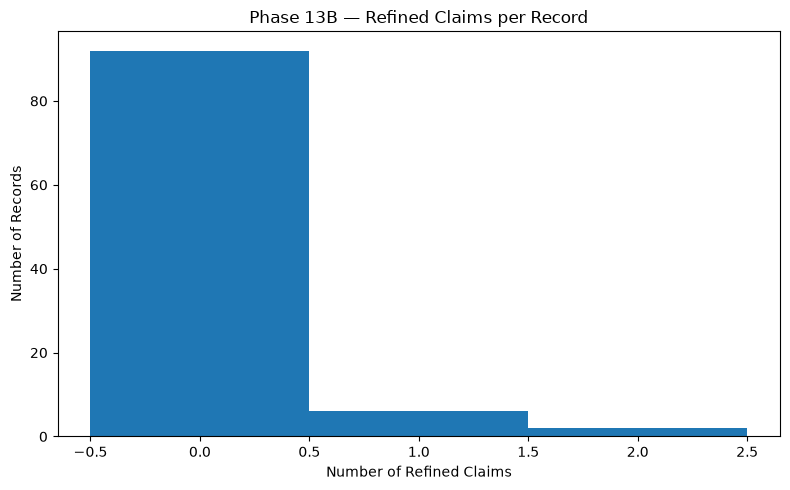

Saved: d:\downloads\misleading-health-infographic-detection\outputs\phase13b\visualizations\phase13b_claims_per_record.png


In [32]:
# ============================================================
# CELL 31 — Claims per record visualization
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.hist(
    record_claim_counts[
        "num_refined_claims"
    ],
    bins=range(
        0,
        int(
            record_claim_counts[
                "num_refined_claims"
            ].max()
        ) + 2
    ),
    align="left"
)

plt.xlabel(
    "Number of Refined Claims"
)

plt.ylabel(
    "Number of Records"
)

plt.title(
    "Phase 13B — Refined Claims per Record"
)

plt.tight_layout()

CLAIMS_PLOT = (
    VIS_DIR /
    "phase13b_claims_per_record.png"
)

plt.savefig(
    CLAIMS_PLOT,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    CLAIMS_PLOT
)

In [33]:
# ============================================================
# CELL 32 — Baseline vs refined comparison
# ============================================================

comparison = pd.DataFrame([
    {
        "pipeline": "Phase 13 baseline",
        "total_claims": baseline_count,
        "records_with_claims": baseline_records
    },
    {
        "pipeline": "Phase 13B refined",
        "total_claims": refined_count,
        "records_with_claims": refined_records
    }
])

display(
    comparison
)

COMPARISON_PATH = (
    METRICS_DIR /
    "phase13_vs_phase13b_comparison.csv"
)

comparison.to_csv(
    COMPARISON_PATH,
    index=False,
    encoding="utf-8-sig"
)

,pipeline,total_claims,records_with_claims
0,Phase 13 baseline,12,10
1,Phase 13B refined,10,8


In [34]:
# ============================================================
# CELL 33 — Phase 14 evidence retrieval input
# ============================================================

PHASE14_INPUT = (
    MANIFEST_DIR /
    "phase14_evidence_retrieval_input.csv"
)

phase14_input = refined_claims[
    [
        "claim_id",
        "record_key",
        "image_path",
        "label",
        "source",
        "phase11_split",
        "claim_text",
        "claim_type",
        "topics",
        "health_terms",
        "quantitative_values",
        "candidate_score"
    ]
].copy()

phase14_input.to_csv(
    PHASE14_INPUT,
    index=False,
    encoding="utf-8-sig"
)

print(
    "Phase 14 input saved:"
)

print(
    PHASE14_INPUT
)

print(
    "\nRecords:",
    len(phase14_input)
)

Phase 14 input saved:
d:\downloads\misleading-health-infographic-detection\outputs\phase13b\manifests\phase14_evidence_retrieval_input.csv

Records: 10


In [35]:
# ============================================================
# CELL 34 — Phase 14 JSONL
# ============================================================

PHASE14_JSONL = (
    MANIFEST_DIR /
    "phase14_evidence_retrieval_input.jsonl"
)

with open(
    PHASE14_JSONL,
    "w",
    encoding="utf-8"
) as f:

    for record in phase14_input.to_dict(
        orient="records"
    ):

        f.write(
            json.dumps(
                json_safe(record),
                ensure_ascii=False
            )
            + "\n"
        )

print(
    "Phase 14 JSONL saved:"
)

print(
    PHASE14_JSONL
)

Phase 14 JSONL saved:
d:\downloads\misleading-health-infographic-detection\outputs\phase13b\manifests\phase14_evidence_retrieval_input.jsonl


In [36]:
# ============================================================
# CELL 35 — Phase 13B summary
# ============================================================

summary = {

    "phase":
        "Phase 13B — Refined Medical Claim Extraction",

    "input_records":
        int(len(df)),

    "baseline_claims":
        int(baseline_count),

    "baseline_records_with_claims":
        int(baseline_records),

    "refined_claims":
        int(refined_count),

    "refined_records_with_claims":
        int(refined_records),

    "claim_types":
        claim_type_stats.to_dict(
            orient="records"
        ),

    "claim_manifest":
        str(CLAIM_MANIFEST_PATH),

    "phase14_input":
        str(PHASE14_INPUT),

    "phase14_jsonl":
        str(PHASE14_JSONL)
}

summary_path = (
    METRICS_DIR /
    "phase13b_summary.json"
)

with open(
    summary_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        json_safe(summary),
        f,
        indent=2,
        ensure_ascii=False
    )

print(
    json.dumps(
        json_safe(summary),
        indent=2,
        ensure_ascii=False
    )
)

{
  "phase": "Phase 13B — Refined Medical Claim Extraction",
  "input_records": 100,
  "baseline_claims": 12,
  "baseline_records_with_claims": 10,
  "refined_claims": 10,
  "refined_records_with_claims": 8,
  "claim_types": [
    {
      "claim_type": "unknown",
      "count": 4
    },
    {
      "claim_type": "quantitative",
      "count": 4
    },
    {
      "claim_type": "general_health",
      "count": 2
    }
  ],
  "claim_manifest": "d:\\downloads\\misleading-health-infographic-detection\\outputs\\phase13b\\manifests\\phase13b_claims_manifest.csv",
  "phase14_input": "d:\\downloads\\misleading-health-infographic-detection\\outputs\\phase13b\\manifests\\phase14_evidence_retrieval_input.csv",
  "phase14_jsonl": "d:\\downloads\\misleading-health-infographic-detection\\outputs\\phase13b\\manifests\\phase14_evidence_retrieval_input.jsonl"
}


In [37]:
# ============================================================
# CELL 36 — Phase 13B report
# ============================================================

REPORT_PATH = (
    REPORTS_DIR /
    "phase13b_report.txt"
)

report = f"""
PHASE 13B — REFINED MEDICAL CLAIM EXTRACTION
============================================================

Input OCR records:
{len(df)}

Phase 13 baseline claims:
{baseline_count}

Phase 13 baseline records with claims:
{baseline_records}

Phase 13B refined claims:
{refined_count}

Phase 13B records with claims:
{refined_records}

Claim count multiplier:
{(refined_count / baseline_count) if baseline_count else 0:.2f}x

Claim type distribution:
{claim_type_stats.to_string(index=False)}

Outputs:

Claim manifest:
{CLAIM_MANIFEST_PATH}

Phase 14 CSV:
{PHASE14_INPUT}

Phase 14 JSONL:
{PHASE14_JSONL}

Phase 13B completed.
"""

with open(
    REPORT_PATH,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        report.strip()
    )

print(
    "Report saved:"
)

print(
    REPORT_PATH
)

Report saved:
d:\downloads\misleading-health-infographic-detection\outputs\phase13b\reports\phase13b_report.txt


In [38]:
# ============================================================
# CELL 37 — Final artifact check
# ============================================================

expected_files = [

    CLAIM_MANIFEST_PATH,

    CLAIMS_JSONL_PATH,

    SOURCE_STATS_PATH,

    LABEL_STATS_PATH,

    TYPE_STATS_PATH,

    COMPARISON_PATH,

    CLAIMS_PLOT,

    PHASE14_INPUT,

    PHASE14_JSONL,

    summary_path,

    REPORT_PATH
]

print(
    "PHASE 13B ARTIFACT CHECK"
)

print("=" * 70)

all_exist = True

for path in expected_files:

    exists = Path(path).exists()

    print(
        f"{'✓' if exists else '✗'} {path}"
    )

    if not exists:
        all_exist = False

json_count = len(
    list(
        CLAIMS_DIR.glob(
            "record_*.json"
        )
    )
)

print("=" * 70)

print(
    "Record-level JSON files:",
    json_count
)

print(
    "Records with refined claims:",
    refined_records
)

print("=" * 70)

if all_exist:
    print(
        "✓ PHASE 13B ARTIFACT CHECK PASSED"
    )
else:
    print(
        "✗ SOME PHASE 13B ARTIFACTS ARE MISSING"
    )

PHASE 13B ARTIFACT CHECK
✓ d:\downloads\misleading-health-infographic-detection\outputs\phase13b\manifests\phase13b_claims_manifest.csv
✓ d:\downloads\misleading-health-infographic-detection\outputs\phase13b\manifests\phase13b_claims.jsonl
✓ d:\downloads\misleading-health-infographic-detection\outputs\phase13b\metrics\source_wise_claim_stats.csv
✓ d:\downloads\misleading-health-infographic-detection\outputs\phase13b\metrics\label_wise_claim_stats.csv
✓ d:\downloads\misleading-health-infographic-detection\outputs\phase13b\metrics\claim_type_stats.csv
✓ d:\downloads\misleading-health-infographic-detection\outputs\phase13b\metrics\phase13_vs_phase13b_comparison.csv
✓ d:\downloads\misleading-health-infographic-detection\outputs\phase13b\visualizations\phase13b_claims_per_record.png
✓ d:\downloads\misleading-health-infographic-detection\outputs\phase13b\manifests\phase14_evidence_retrieval_input.csv
✓ d:\downloads\misleading-health-infographic-detection\outputs\phase13b\manifests\phase14_ev

In [39]:
display(
    refined_claims[
        [
            "claim_id",
            "record_key",
            "claim_text",
            "candidate_score",
            "claim_type",
            "topics",
            "health_terms",
            "quantitative_values"
        ]
    ]
    .head(50)
)

,claim_id,record_key,claim_text,candidate_score,claim_type,topics,health_terms,quantitative_values
0,claim13b_000000,record_000036,OUE TO NON-RECEIPT OF VACCINE DOSES.,3,unknown,"[medication_treatment, immunity_infection]","[vaccine, dose]",[]
1,claim13b_000001,record_000050,"""to help reduce hesitance.",3,unknown,[other],[],[]
2,claim13b_000002,record_000050,Visit the COVID-19 Information Center for,4,general_health,[disease_conditions],"[covid-19, covid]",[]
3,claim13b_000003,record_000062,Each vial contains 5 doses of 0.5 mL.,4,quantitative,[medication_treatment],[dose],[0.5 ml]
4,claim13b_000004,record_000073,contains 6 doses of 0.3 mL.,4,quantitative,[medication_treatment],[dose],[0.3 ml]
5,claim13b_000005,record_000107,OUE TO NON-RECEIPT OF VACCINE DOSES.,3,unknown,"[medication_treatment, immunity_infection]","[vaccine, dose]",[]
6,claim13b_000006,record_000121,"""to help reduce hesitance.",3,unknown,[other],[],[]
7,claim13b_000007,record_000121,Visit the COVID-19 Information Center for,4,general_health,[disease_conditions],"[covid-19, covid]",[]
8,claim13b_000008,record_000136,Each vial contains 5 doses of 0.5 mL.,4,quantitative,[medication_treatment],[dose],[0.5 ml]
9,claim13b_000009,record_000147,contains 6 doses of 0.3 mL.,4,quantitative,[medication_treatment],[dose],[0.3 ml]
